In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression

In [2]:
!pip install category_encoders
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [3]:
flight_fare = pd.read_excel("/content/Flight_Fare.xlsx")

**Basic Checks**

In [4]:
flight_fare.shape

(10683, 11)

In [5]:
flight_fare.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [6]:
flight_fare.tail(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [7]:
flight_fare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
flight_fare.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [9]:
flight_fare.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [10]:
flight_fare[['Route', 'Total_Stops']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Route        10682 non-null  object
 1   Total_Stops  10682 non-null  object
dtypes: object(2)
memory usage: 167.1+ KB


In [11]:
flight_fare['Route'] = flight_fare['Route'].fillna(flight_fare['Route'].mode()[0])
flight_fare['Total_Stops'] = flight_fare['Total_Stops'].fillna(flight_fare['Total_Stops'].mode()[0])

In [12]:
flight_fare.duplicated().sum()

np.int64(220)

In [13]:
flight_fare.drop_duplicates(inplace=True)

**Uni-Variate Analysis**

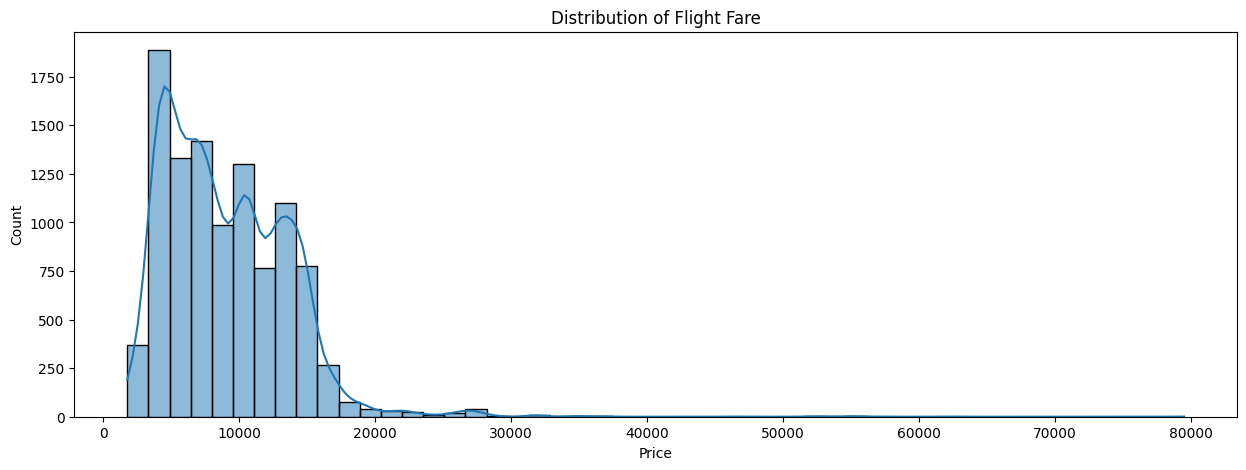

In [14]:
plt.figure(figsize=(15,5))
sns.histplot(flight_fare['Price'], bins =50, kde = True),
plt.title('Distribution of Flight Fare')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

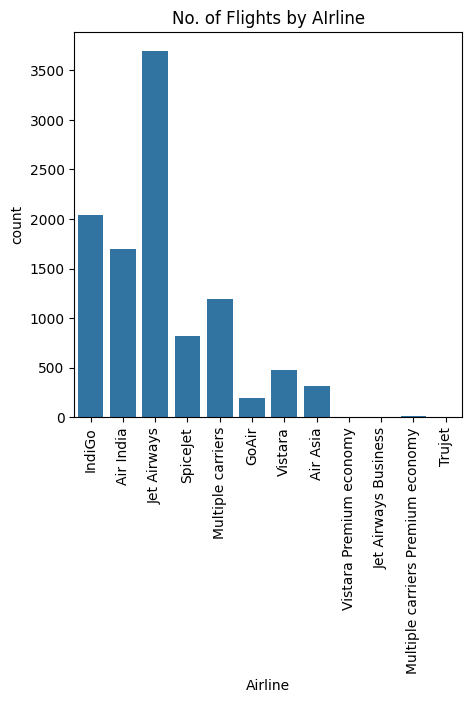

In [15]:
plt.figure(figsize=(5,5))
sns.countplot(x='Airline', data = flight_fare)
plt.xticks(rotation=90)
plt.title('No. of Flights by AIrline')
plt.show()

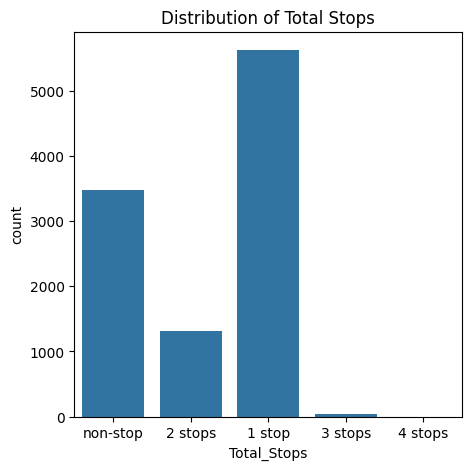

In [16]:
plt.figure(figsize=(5,5))
sns.countplot(x='Total_Stops', data = flight_fare)
plt.title('Distribution of Total Stops')
plt.show()

* Right-Skewed ditribution of Price
* Jet Airways counts are high
* Most Flights have 1 stops

**Multi-Variate Analysis**

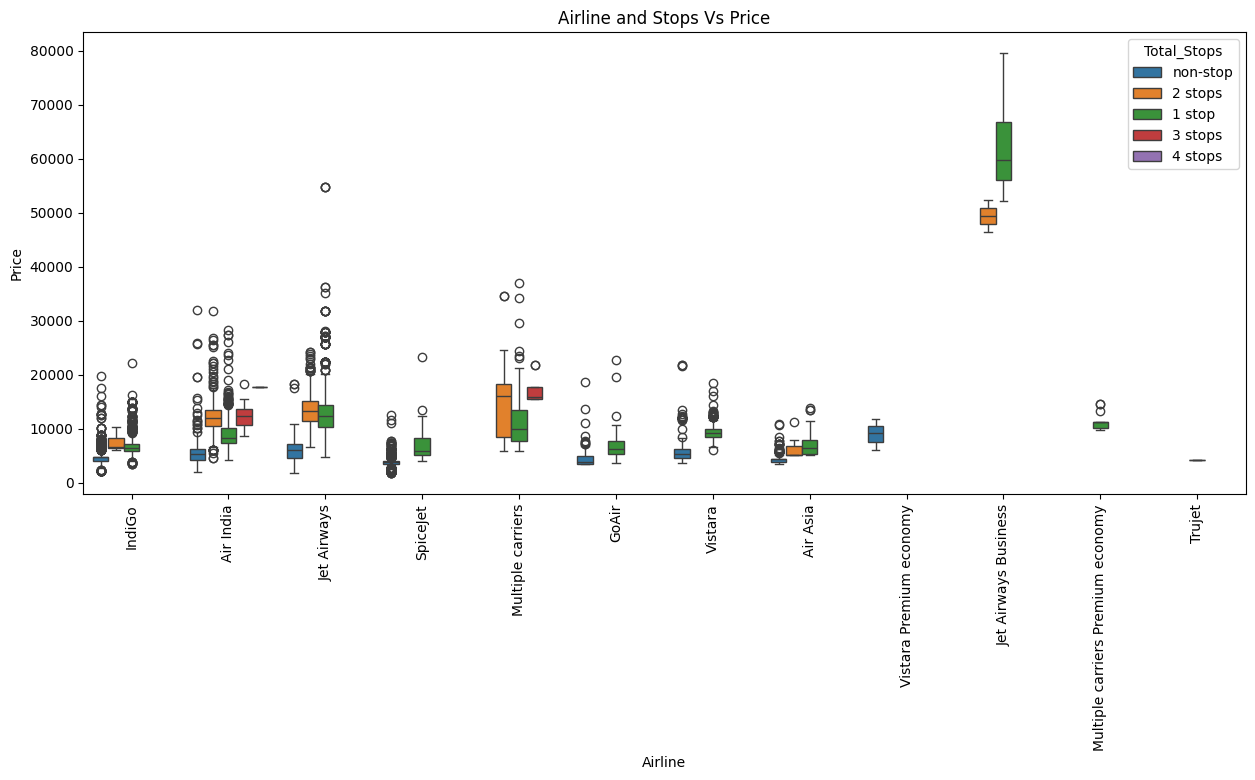

In [17]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Airline', y='Price', hue = 'Total_Stops', data = flight_fare)
plt.xticks(rotation = 90)
plt.title('Airline and Stops Vs Price')
plt.show()

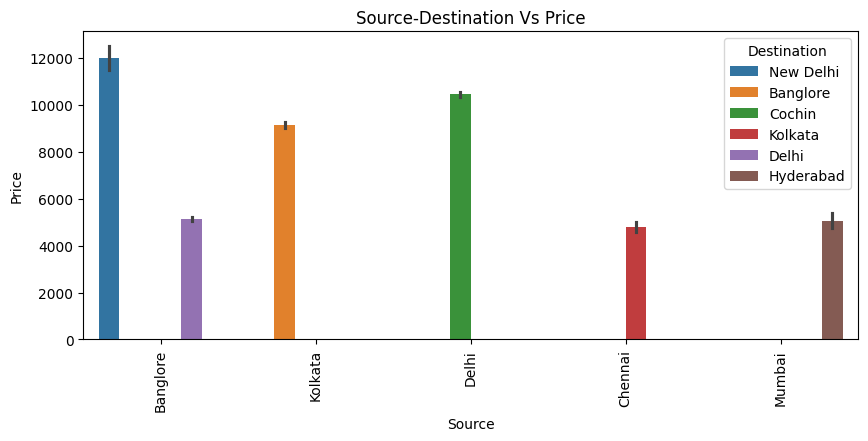

In [18]:
plt.figure(figsize=(10,4))
sns.barplot(x='Source', y='Price', hue = 'Destination', data = flight_fare)
plt.xticks(rotation = 90)
plt.title('Source-Destination Vs Price')
plt.show()

* Non-Stop Indigo Flights are at low-cost
* Bangalore to NewDelhi is expensive

**Feature Engineering**

In [19]:
flight_fare['Code'] = flight_fare['Route'].str.split('→')

In [20]:
flight_fare['Code'] = flight_fare['Code'].apply(lambda x: [s.strip() for s in x] if isinstance(x, list) else x)
flight_fare['Source_code'] = flight_fare['Code'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
flight_fare['Destination_code'] = flight_fare['Code'].apply(lambda x: x[-1] if isinstance(x, list) and len(x) > 0 else None)

In [21]:
flight_fare['First_stop'] = flight_fare['Code'].apply(lambda x: x[1] if isinstance(x, list) and len(x)>2 else None)

In [22]:
flight_fare['Second_stop'] = flight_fare['Code'].apply(lambda x: x[2] if isinstance(x, list) and len(x)>3 else None)

In [23]:
flight_fare['Third_stop'] = flight_fare['Code'].apply(lambda x: x[3] if isinstance(x, list) and len(x)>4 else None)

In [24]:
flight_fare['Fourth_stop'] = flight_fare['Code'].apply(lambda x: x[4] if isinstance(x, list) and len(x)>5 else None)

* Code is splitted into Source Code, Destination Code and Stops(1-4)

In [25]:
stops_col = ['First_stop', 'Second_stop', 'Third_stop', 'Fourth_stop']
for col in stops_col:
  print(col, flight_fare[col].isnull().sum())
  flight_fare[col] = flight_fare[col].fillna(0)

First_stop 3475
Second_stop 9101
Third_stop 10419
Fourth_stop 10462


In [26]:
flight_fare.isnull().sum().sum()

np.int64(0)

In [27]:
flight_fare.drop(columns=['Route','Code', 'Source', 'Destination', 'Total_Stops', 'Additional_Info'], inplace=True)

In [28]:
flight_fare['Date_of_Journey'] = pd.to_datetime(flight_fare['Date_of_Journey'])

/tmp/ipykernel_347/3164394867.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  flight_fare['Date_of_Journey'] = pd.to_datetime(flight_fare['Date_of_Journey'])


In [29]:
flight_fare['Journey_month'] = flight_fare['Date_of_Journey'].dt.month
flight_fare['Journey_date'] = flight_fare['Date_of_Journey'].dt.day
flight_fare['Journey_year'] = flight_fare['Date_of_Journey'].dt.year

In [30]:
flight_fare['Journey_day'] = flight_fare['Date_of_Journey'].dt.day_of_week

In [31]:
flight_fare['Week_end'] = np.where(flight_fare['Journey_day']>5, 1, 0)

In [32]:
flight_fare['Journey_year'].value_counts()

,count
Journey_year,
2019,10463


In [33]:
from datetime import date
import holidays
holidays = holidays.CountryHoliday('IN', years = 2019)
flight_fare['Holidays'] = flight_fare['Date_of_Journey'].apply(lambda x: 1 if x in holidays else 0)

In [34]:
from datetime import timedelta
def fest_range(journey_date, holidays_list, range = 4):
  for i in holidays_list:
    # Convert Timestamp to datetime.date before comparison
    date_diff = abs((journey_date.date() - i).days)
    if date_diff <= range:
      return 1
  return 0

In [35]:
flight_fare['Near_to_holidays'] = flight_fare.apply(lambda x: fest_range(x['Date_of_Journey'], holidays), axis = 1)

* Date of Journey is split into date, Month and Year.
* Created Week end feature to check for week ends.
* Created Holidays feature to check for holidays.
* Created Near_to_Holidays feature to check for nearby holidays around Journey date.

In [36]:
flight_fare['Dep_Time'] = pd.to_datetime(flight_fare['Dep_Time'], format = 'mixed').dt.time

In [37]:
flight_fare['Dep_hour'] = flight_fare['Dep_Time'].apply(lambda x: x.hour)

In [38]:
flight_fare['Arrival_Time'] = pd.to_datetime(flight_fare['Arrival_Time'], format = 'mixed').dt.time

In [39]:
flight_fare['Arrival_hour'] = flight_fare['Arrival_Time'].apply(lambda x: x.hour)

In [40]:
def time_slot(hour):
  if 5 <= hour < 12:
    return 'Morning'
  elif 12 <= hour <17:
    return 'Afternoon'
  elif 17 <= hour <20:
    return 'Evening'
  else:
    return 'Night'

In [41]:
flight_fare['Dep_slot'] = flight_fare['Dep_hour'].apply(time_slot)

In [42]:
flight_fare['Arrival_slot'] = flight_fare['Arrival_hour'].apply(time_slot)

* Created Dep_slot and Arrival_slot to check for Morning, Afternoon, Evening and Night

In [43]:
import re
def duration_min(duration):
  duration = str(duration).strip().lower()
  hours = 0
  minutes = 0
  hours_match = re.search(r'(\d+)\s*h', duration)
  if hours_match:
    hours = int(hours_match.group(1))
  minutes_match = re.search(r'(\d+)\s*m', duration)
  if minutes_match:
    minutes = int(minutes_match.group(1))
  return hours*60 + minutes

In [44]:
flight_fare['Duration'] = flight_fare['Duration'].apply(duration_min)

In [45]:
flight_fare.drop(columns = ['Date_of_Journey'], inplace = True)

**Encoding and Scaling**

In [46]:
target_encoder = ce.TargetEncoder(cols = ['Airline'])
flight_fare['Airline_encoded'] = target_encoder.fit_transform(flight_fare['Airline'], flight_fare['Price'])

In [47]:
flight_fare.head(2)

,Airline,Dep_Time,Arrival_Time,Duration,Price,Source_code,Destination_code,First_stop,Second_stop,Third_stop,...,Journey_year,Journey_day,Week_end,Holidays,Near_to_holidays,Dep_hour,Arrival_hour,Dep_slot,Arrival_slot,Airline_encoded
0,IndiGo,22:20:00,01:10:00,170,3897,BLR,DEL,0,0,0,...,2019,6,1,0,0,22,1,Night,Night,5668.469897
1,Air India,05:50:00,13:15:00,445,7662,CCU,BLR,IXR,BBI,0,...,2019,2,0,0,0,5,13,Morning,Afternoon,9555.382891


In [48]:
def cyclic_time(df, col_name, period):
  df[col_name+'_sin'] = np.sin(2* np.pi * df[col_name]/period)
  df[col_name+'_cos'] = np.cos(2* np.pi * df[col_name]/period)
  return df

In [49]:
flight_fare = cyclic_time(flight_fare, 'Arrival_hour', 24)
flight_fare = cyclic_time(flight_fare, 'Dep_hour', 24)

<Axes: xlabel='Duration', ylabel='Count'>

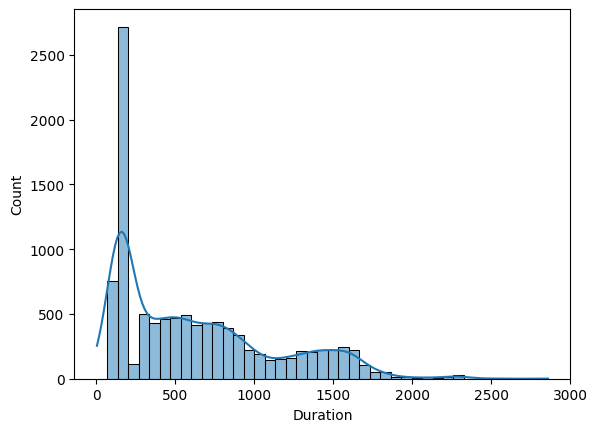

In [50]:
sns.histplot(flight_fare['Duration'], kde=True)

In [51]:
flight_fare['Duration_log'] = np.log(flight_fare['Duration'])
flight_fare['Price'] = np.log1p(flight_fare['Price'])

In [52]:
one_hot_encoder = ce.OneHotEncoder(cols = ['Source_code', 'Destination_code','Journey_day', 'Week_end', 'Holidays', 'Near_to_holidays', 'Dep_slot', 'Arrival_slot'], use_cat_names = True)
flight_fare = one_hot_encoder.fit_transform(flight_fare)

In [53]:
frequeny_encoder = ce.CountEncoder(cols = ['First_stop', 'Second_stop', 'Third_stop','Fourth_stop'], normalize = True)
flight_fare = frequeny_encoder.fit_transform(flight_fare)

In [54]:
flight_fare.drop(columns = ['Airline', 'Dep_Time', 'Arrival_Time', 'Duration', 'Journey_month', 'Journey_date', 'Journey_year','Dep_hour', 'Arrival_hour'], axis = 1, inplace = True)

In [55]:
flight_fare[flight_fare.corr()>0.8]

,Price,Source_code_BLR,Source_code_CCU,Source_code_DEL,Source_code_MAA,Source_code_BOM,Destination_code_DEL,Destination_code_BLR,Destination_code_COK,Destination_code_CCU,...,Arrival_slot_Night,Arrival_slot_Afternoon,Arrival_slot_Morning,Arrival_slot_Evening,Airline_encoded,Arrival_hour_sin,Arrival_hour_cos,Dep_hour_sin,Dep_hour_cos,Duration_log
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
correlation_matrix = flight_fare.corr()
high_corr = correlation_matrix[correlation_matrix > 0.8].stack().reset_index()
high_corr = high_corr[high_corr['level_0'] != high_corr['level_1']]
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
display(high_corr.sort_values(by='Correlation', ascending=False))

,Feature_1,Feature_2,Correlation
2,Source_code_BLR,Destination_code_DEL,1.000000
4,Source_code_CCU,Destination_code_BLR,1.000000
6,Source_code_DEL,Destination_code_COK,1.000000
8,Source_code_MAA,Destination_code_CCU,1.000000
10,Source_code_BOM,Destination_code_HYD,1.000000
11,Destination_code_DEL,Source_code_BLR,1.000000
13,Destination_code_BLR,Source_code_CCU,1.000000
15,Destination_code_COK,Source_code_DEL,1.000000
17,Destination_code_CCU,Source_code_MAA,1.000000
19,Destination_code_HYD,Source_code_BOM,1.000000


<Axes: >

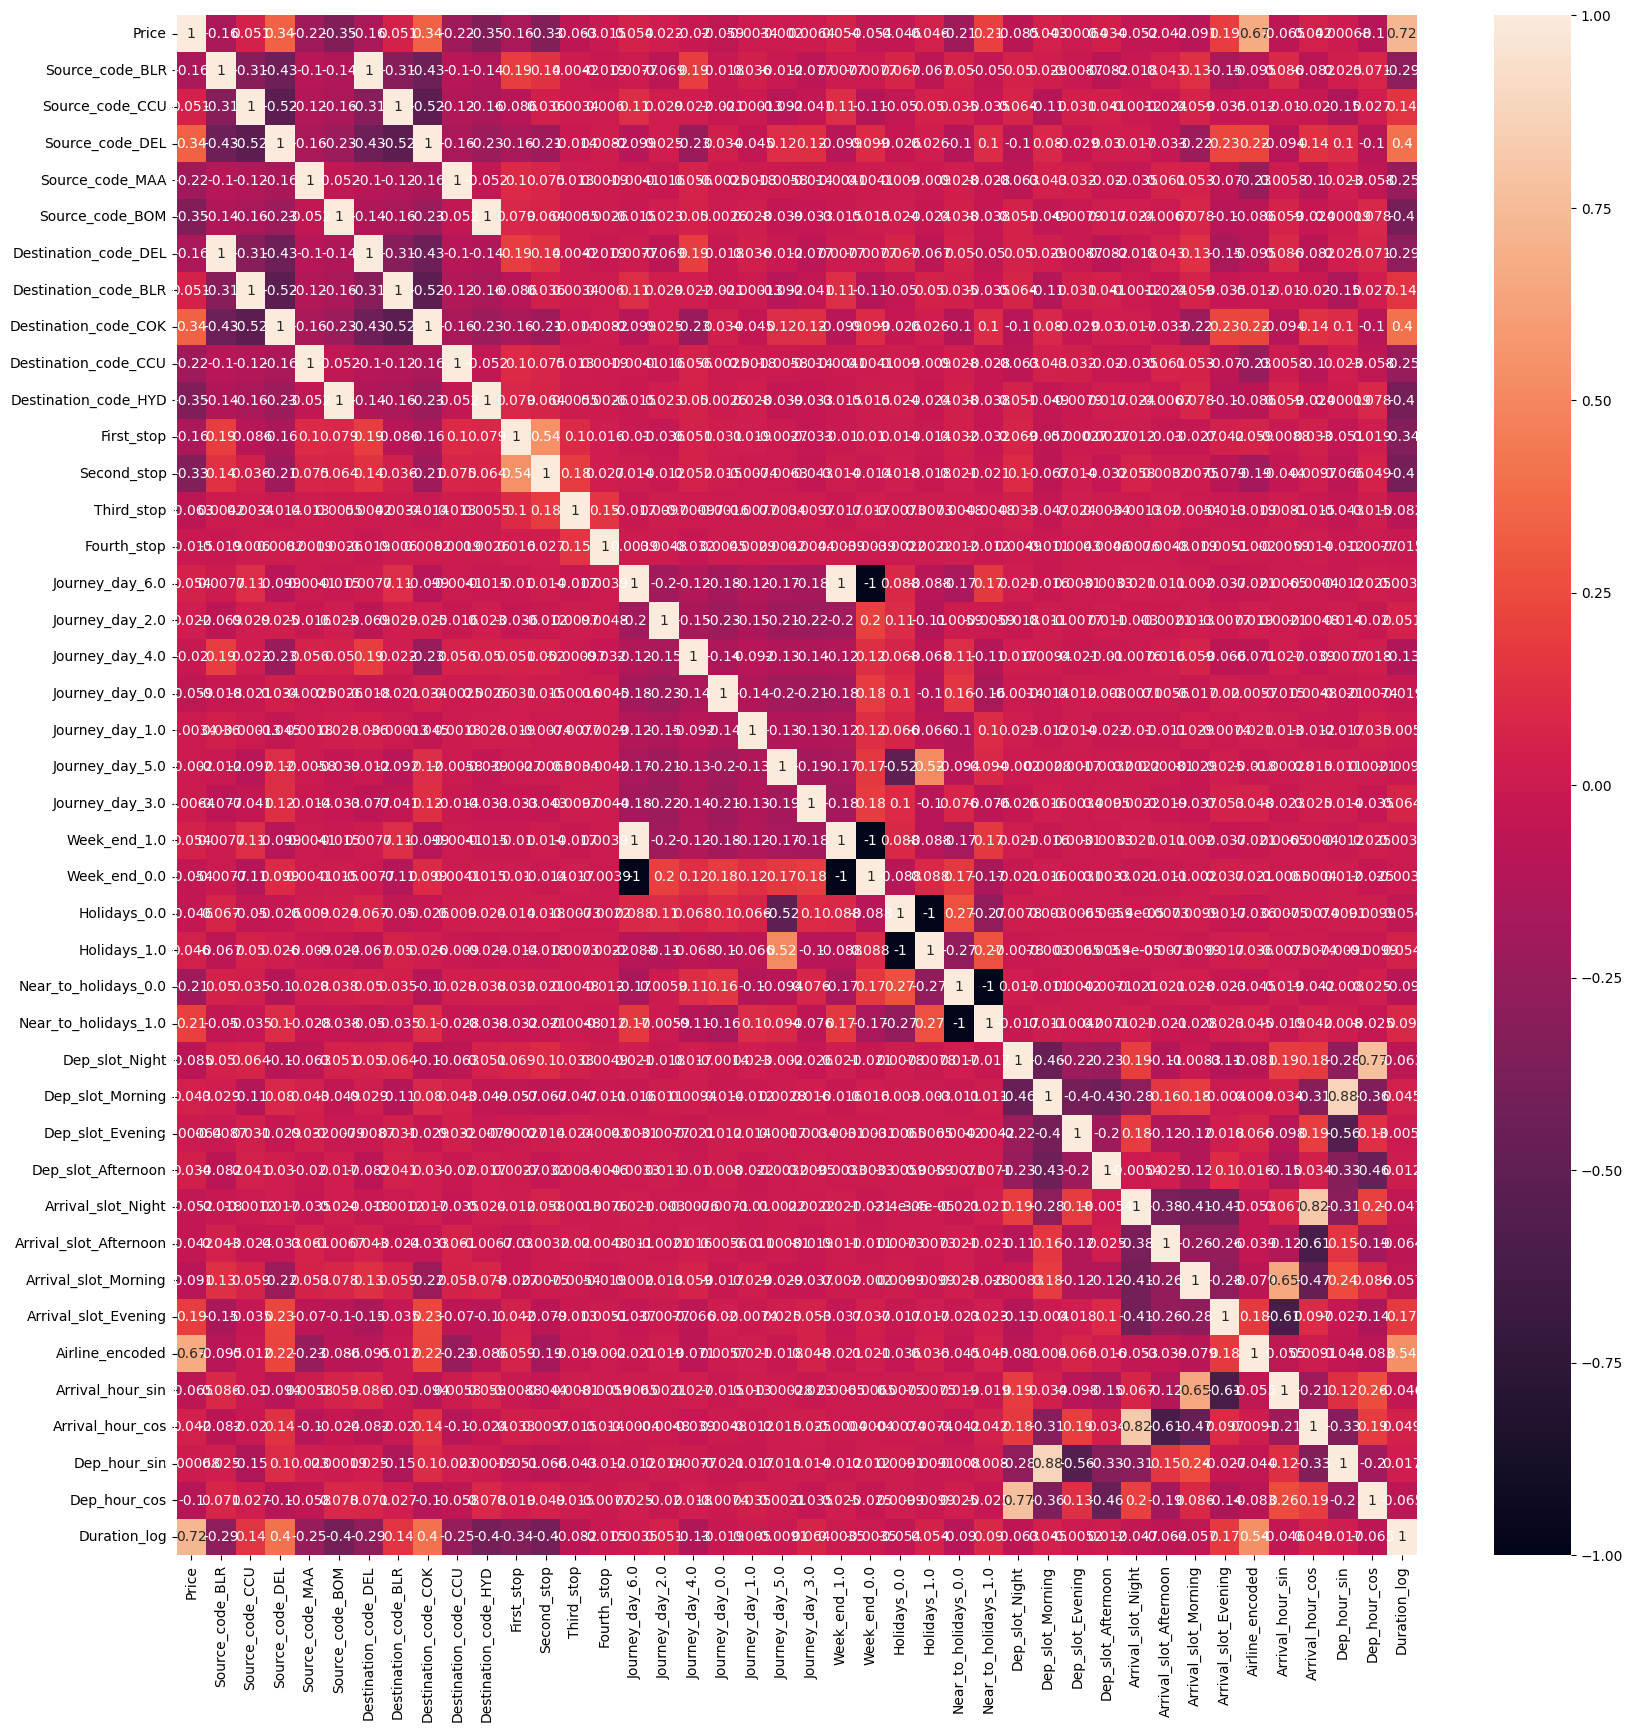

In [57]:
plt.figure(figsize = (20,20))
sns.heatmap(flight_fare.corr(), annot = True)

**Model Building and Evaluation**

**LinearRegression Model**

In [58]:
x = flight_fare.iloc[:,1:]
y = flight_fare['Price']

In [59]:
print(x.shape)
print(y.shape)

(10463, 41)
(10463,)


In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.80, random_state = 42)

In [61]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8370, 41)
(2093, 41)
(8370,)
(2093,)


In [62]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [63]:
y_pred = model.predict(x_test)

In [64]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.6966171060645248 0.08020089877542305 0.21803896203849854 0.28319763200885534


**SVR Model**

In [65]:
from sklearn.svm import SVR

In [66]:
model = SVR(kernel = 'rbf', C = 100, gamma = 0.1, epsilon = 0.1)
model.fit(x_train, y_train)

SVR(C=100, gamma=0.1)

In [67]:
y_pred = model.predict(x_test)

In [68]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.7456762830417957 0.06723184163538372 0.1881868765027295 0.2592910365504055


**KNeighborsRegressor Model**

In [69]:
from sklearn.neighbors import KNeighborsRegressor

In [70]:
model = KNeighborsRegressor(n_neighbors = 5, metric = 'euclidean', weights = 'distance')
model.fit(x_train, y_train)

KNeighborsRegressor(metric='euclidean', weights='distance')

In [71]:
y_pred = model.predict(x_test)

In [72]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.6830626398788353 0.0837840947704635 0.2086927949575451 0.2894548233670731


**RandomForestRegressor Model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(n_estimators = 300, random_state = 42, n_jobs = -1)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.7946945155757723 0.0542736083790165 0.16555810117247438 0.23296696842903825


In [ ]:
feature_importance = model.feature_importances_
feature_names = [i for i in x.columns]
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending = False)
print(importance_df)

                   feature  importance
40            Duration_log    0.636664
35         Airline_encoded    0.130952
16         Journey_day_4.0    0.028371
10              First_stop    0.026096
39            Dep_hour_cos    0.017049
25    Near_to_holidays_0.0    0.016187
26    Near_to_holidays_1.0    0.014993
11             Second_stop    0.013964
37        Arrival_hour_cos    0.013942
38            Dep_hour_sin    0.013408
36        Arrival_hour_sin    0.011068
15         Journey_day_2.0    0.008682
19         Journey_day_5.0    0.006435
20         Journey_day_3.0    0.004912
17         Journey_day_0.0    0.004806
9     Destination_code_HYD    0.004056
4          Source_code_BOM    0.003871
22            Week_end_0.0    0.003808
18         Journey_day_1.0    0.003530
0          Source_code_BLR    0.002850
14         Journey_day_6.0    0.002828
5     Destination_code_DEL    0.002785
1          Source_code_CCU    0.002760
6     Destination_code_BLR    0.002747
21            Week_end_1.

**GradientBoostingRegressor Model**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)
model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

In [ ]:
feature_importances = model.feature_importances_
feature_names = [i for i in x.columns]
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values('importance', ascending = False)
print(importance_df)

In [ ]:
model = GradientBoostingRegressor(random_state = 42)
model


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample' : [0.8, 0.9, 1.0]
}

In [ ]:
grid_search = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

In [ ]:
grid_search.fit(x_train, y_train)

In [ ]:
print("param : ", grid_search.best_params_)
print("score : ", grid_search.best_score_)
print("Cross_Validation_RMSE", np.sqrt(-grid_search.best_score_))

In [ ]:
model = grid_search.best_estimator_

In [ ]:
model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

**xgboost Model**

In [73]:
pip install xgboost

In [74]:
import xgboost as xgb

In [75]:
modelxgb = xgb.XGBRegressor(objective = 'reg:squarederror', n_estimators = 100, learning_rate = 0.1, max_depth = 6, random_state = 42)
modelxgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [76]:
y_pred = modelxgb.predict(x_test)

In [77]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.8408915590672623 0.04206117161067051 0.15296448857319297 0.2050882044649826


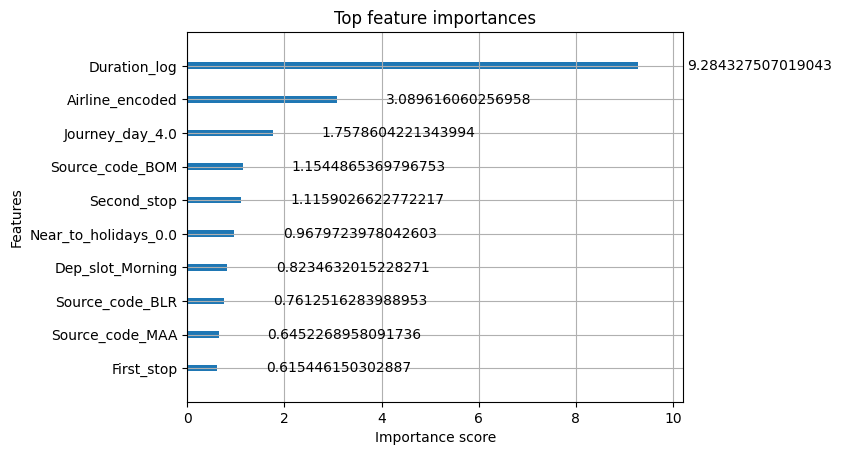

In [78]:
xgb.plot_importance(modelxgb, max_num_features = 10, importance_type = 'gain')
plt.title("Top feature importances")
plt.show()

In [79]:
xgb_model = xgb.XGBRegressor(objective = 'reg:squarederror', random_state = 42)
xgb_model


param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample' : [0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(x_train, y_train)

print("param : ", grid_search.best_params_)
print("score : ", grid_search.best_score_)
print("Cross_Validation_RMSE", np.sqrt(-grid_search.best_score_))

xgb_model = grid_search.best_estimator_
xgb_model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
param :  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
score :  -0.040659109341209684
Cross_Validation_RMSE 0.2016410408156278
0.8408915590672623 0.04206117161067051 0.15296448857319297 0.2050882044649826


**lightgbm Model**

In [80]:
import lightgbm as lgb

In [81]:
model = lgb.LGBMRegressor(objective = 'regression',
                          n_estimators = 100,
                          learning_rate = 0.1,
                          random_state = 42,
                          verbose = -1)

In [82]:
model.fit(x_train, y_train)

LGBMRegressor(objective='regression', random_state=42, verbose=-1)

In [83]:
y_pred = model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

0.8366283231325091 0.04318818094604724 0.15467362130904116 0.20781766273839006


In [84]:
model = lgb.LGBMRegressor(objective = 'regression', random_state = 42)
model


param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample' : [0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(x_train, y_train)

print("param : ", grid_search.best_params_)
print("score : ", grid_search.best_score_)
print("Cross_Validation_RMSE", np.sqrt(-grid_search.best_score_))

model = grid_search.best_estimator_
model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
param :  {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
score :  -0.041708733343444396
Cross_Validation_RMSE 0.20422716113055187
0.8366283231325091 0.04318818094604724 0.15467362130904116 0.20781766273839006


In [ ]:
lgb.plot_importance(model, max_num_features = 10, importance_type = 'gain')
plt.title("Feature_importance")
plt.show()

**Catboost Model**

In [ ]:
pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
model = CatBoostRegressor(
    iterations = 100,
    learning_rate = 0.1,
    depth = 6,
    loss_function = 'RMSE',
    verbose = 0,
    random_seed = 42
)

In [ ]:
model.fit(x_train, y_train, eval_set = (x_test, y_test), early_stopping_rounds = 10)

In [ ]:
y_pred = model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

In [ ]:
model = CatBoostRegressor(random_state = 42)
model


param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample' : [0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(x_train, y_train)

print("param : ", grid_search.best_params_)
print("score : ", grid_search.best_score_)
print("Cross_Validation_RMSE", np.sqrt(-grid_search.best_score_))

model = grid_search.best_estimator_
model.predict(x_test)
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

**DecisionTreeRegressor Model**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model = DecisionTreeRegressor(max_depth = 3, random_state = 42)

In [ ]:
model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [ ]:
print(r2_on_test, mse, mae, rmse)

**AdaBoostRegressor Model**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
base_model = DecisionTreeRegressor(max_depth = 3, random_state = 42)
model = AdaBoostRegressor(
    estimator = base_model,
    n_estimators = 100,
    learning_rate = 0.1,
    loss= 'linear',
    random_state = 42
)

In [ ]:
model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2_on_test = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators' : [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

In [ ]:
grid_search = GridSearchCV(
    estimator = AdaBoostRegressor(random_state = 42),
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

In [ ]:
grid_search.fit(x_train, y_train)

In [ ]:
print("parameters: ", grid_search.best_params_)
print("Score : ", grid_search.best_score_)

In [ ]:
model = grid_search.best_estimator_

In [ ]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2_on_test, mse, mae, rmse)

* XGBOOSTRegressor model performed best among all the models and was selected as the final model for predicting the Flight Fare Prediction.

**Deployment**

In [94]:
import pickle
pickle.dump(xgb_model, open("model.pkl", "wb"))
pickle.dump(x.columns, open("columns.pkl", "wb"))

In [95]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

model = pickle.load(open("model.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

st.title("Flight Fare Prediction")

def create_input_df():
    return pd.DataFrame(0, index=[0], columns=columns)

# User Inputs
source = st.selectbox("Source", ["BLR","CCU","DEL","MAA","BOM"])
destination = st.selectbox("Destination", ["DEL","BLR","COK","CCU","HYD"])
duration = st.number_input("Duration (minutes)", min_value=30)
dep_hour = st.slider("Departure Hour", 0, 23)
arr_hour = st.slider("Arrival Hour", 0, 23)

# Prediction
if st.button("Predict Price"):

    df = create_input_df()

    # Set source & destination
    if f"Source_code_{source}" in df.columns:
        df[f"Source_code_{source}"] = 1

    if f"Destination_code_{destination}" in df.columns:
        df[f"Destination_code_{destination}"] = 1

    # Time features
    df['Dep_hour_sin'] = np.sin(2 * np.pi * dep_hour / 24)
    df['Dep_hour_cos'] = np.cos(2 * np.pi * dep_hour / 24)
    df['Arrival_hour_sin'] = np.sin(2 * np.pi * arr_hour / 24)
    df['Arrival_hour_cos'] = np.cos(2 * np.pi * arr_hour / 24)

    # Duration
    df['Duration_log'] = np.log1p(duration)

    # Prediction
    pred = np.expm1(model.predict(df))

    st.success(f"Estimated Flight Price: Rs {int(pred[0])}")


Writing app.py


In [96]:
!pip install streamlit pyngrok

In [97]:
!streamlit run app.py &>/content/logs.txt &

In [98]:
!tail -n 20 /content/logs.txt

In [99]:
from pyngrok import ngrok
ngrok.kill()

public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://gerard-nondisturbing-valiantly.ngrok-free.dev" -> "http://localhost:8501">

The Model was Deployed as the Web Application using Streamlit and Nygrok.

### Conclusion:
In this project, the Machine learning model was developed to predict Flight Fare Prediction using given Flight Fare data file.
Exploratory Data Analysis shows how the features impact the Price.
Multiple Machine learning model was trained and evaluated.
Among them, XGBoostRegressor was selected as it achieved 0.84 as R2 score.
The final model was deployed using Streamlit and Nygrok which helps the users to plan their travel effectively.

### Challenges faced:
The Arrival time is not in correct format, so changed into time format.
The Duration is changed into minutes.
The Route was splitted into Source Code, Destination Code, Stop Codes.
The categorical features were encoded with OneHotEncoding, TargetEncoding and CountEncoder according to the need. Many new features were created to know whether the journey date is in weekend or holiday or near to holiday, also to know the slot of Arrival and Departure.